# Stage 3: frequency models (D019-D022)

Display only. Run `make all` first; this notebook reads `reports/`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from src.config import load_config

cfg = load_config()
T, F = cfg["paths"]["tables"], cfg["paths"]["figures"]
pd.set_option("display.width", 200)


def show(name):
    plt.figure(figsize=(12, 5))
    plt.imshow(mpimg.imread(F / name))
    plt.axis("off")
    plt.show()

In [2]:
pd.read_csv(T / "frequency_models_stage3.csv")

,model,n_params,cv_deviance_mean,cv_deviance_sd,cv_fold_0,cv_fold_1,cv_fold_2,cv_fold_3,cv_fold_4,holdout_deviance,holdout_gini,holdout_predicted_over_actual
0,Intercept only,1,0.252058,0.003117,0.254593,0.248683,0.253992,0.254401,0.248620,0.255160,0.000000,0.986858
1,GLM-A (main effects),72,0.239260,0.003246,0.242192,0.236385,0.240904,0.241662,0.235158,0.242651,0.293981,0.982392
2,GBM (LightGBM Poisson),565,0.237682,0.003109,0.240851,0.234626,0.239102,0.239752,0.234081,0.240744,0.315830,0.983453


In [3]:
pd.read_csv(T / "gbm_chosen.csv")

,learning_rate,num_leaves,min_data_in_leaf,feature_fraction,lambda_l2,n_rounds,chosen_trial
0,0.03,15,1000,0.8,0.0,565,3


In [4]:
pd.read_csv(T / "log_exposure_diagnostic.csv")

,coef_log_exposure,se,ci_lower_95,ci_upper_95,z_test_coef_equals_1,cv_deviance_mean_free_exposure,cv_deviance_sd_free_exposure,cv_fold_0_free_exposure,cv_fold_1_free_exposure,cv_fold_2_free_exposure,cv_fold_3_free_exposure,cv_fold_4_free_exposure
0,0.641005,0.009792,0.621812,0.660197,-36.661385,0.237128,0.003151,0.24005,0.233844,0.238403,0.239701,0.233641


In [5]:
pd.read_csv(T / "exposure_by_segment.csv")

,level,factor,policies,exposure,mean_exposure,share_policies_exposure_lt_0_25,frequency_exposure_lt_0_25,frequency_exposure_ge_0_25
0,18-20,DrivAge_band,5431,2061.738933,0.379624,0.438041,0.414718,0.200121
1,21-22,DrivAge_band,7799,3250.063115,0.416728,0.409924,0.305685,0.147240
2,23-24,DrivAge_band,10889,4678.311368,0.429636,0.390945,0.249322,0.118204
3,25-26,DrivAge_band,15156,6558.812696,0.432754,0.390011,0.205536,0.090762
4,27-29,DrivAge_band,31718,13999.439083,0.441372,0.397818,0.136402,0.074104
5,30-34,DrivAge_band,65574,30983.468920,0.472496,0.374493,0.121518,0.064884
6,35-44,DrivAge_band,136383,69826.103424,0.511985,0.335188,0.117294,0.067008
7,45-54,DrivAge_band,131113,71781.797950,0.547480,0.298536,0.142503,0.070621
8,55-64,DrivAge_band,79157,44911.531372,0.567373,0.282022,0.107684,0.062220
9,65-74,DrivAge_band,40769,25853.326675,0.634142,0.233364,0.104630,0.055015


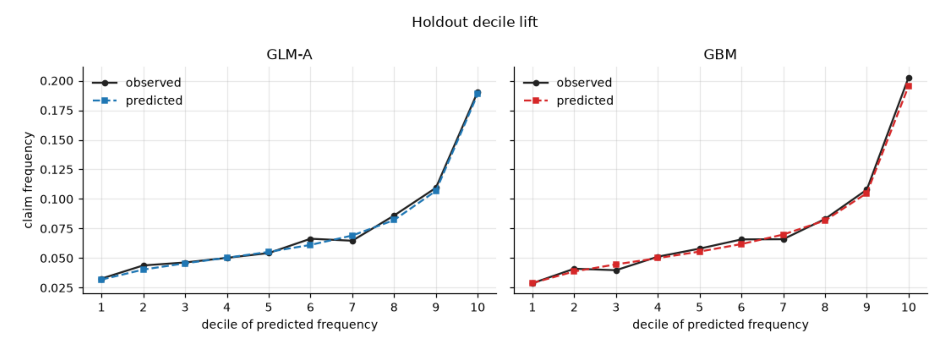

In [6]:
show("lift_glm_a_gbm_holdout.png")

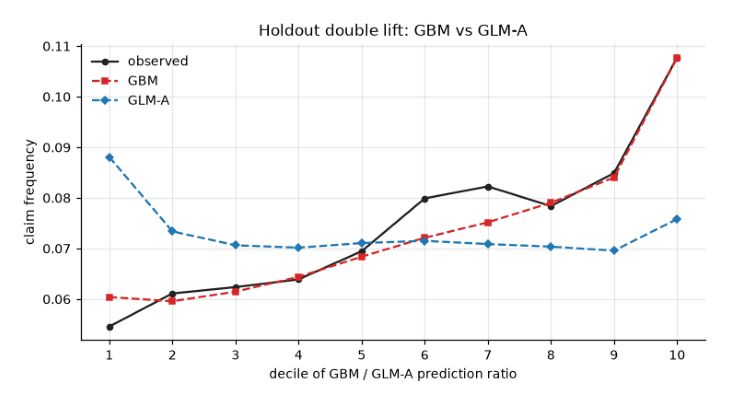

In [7]:
show("double_lift_gbm_vs_glm_a_holdout.png")

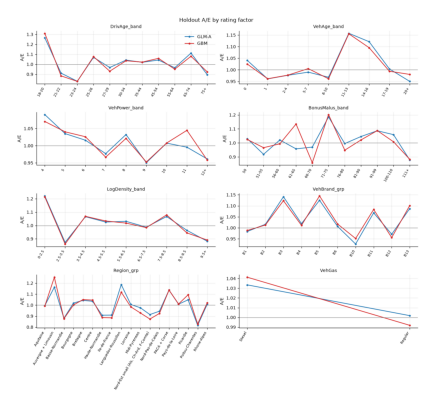

In [8]:
show("ae_by_factor_holdout_stage3.png")